<a href="https://colab.research.google.com/github/abhsrivastava/ActorGuice/blob/master/Fine_Tuning_Example_End_to_End.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Fine-tuning ModernBERT for Bug Severity Classification

# This notebook fine-tunes ModernBERT to read a bug report description and predict:

# - blocker
# - critical
# - major
# - normal
# - minor
# - trivial

In [2]:
# Install Dependencies

%pip install -q --upgrade \
  transformers \
  datasets\
  accelerate \
  evaluate \
  scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 106.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 43.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 118.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 19.0 MB/s eta 0:00:00


In [3]:
# # Imports
# datasets: downloads and manages the bug-report dataset from hugging face
# transformers: supplies ModernBERT, its tokenizer, and the training system.
# torch: performs tensor calculations and GPU processing.
# numpy: helps us choose the largest logit with argmax.
# scikit-learn: calculates accuracy, F1 scores, and the confusion matrix.

import numpy as np
import pandas as pd
import torch

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    set_seed
)

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

print(f'✅ Complted Imports Successfully!')


✅ Complted Imports Successfully!


In [4]:
# Check whether we have GPUs
# Fine-tuning will be much slower without a GPU.

if torch.cuda.is_available():
    print("GPU is available!")
    print("GPU name:", torch.cuda.get_device_name(0))
else:
    print("GPU is not available.")
    print("Change the Colab runtime type to T4 GPU.")

GPU is available!
GPU name: Tesla T4


In [5]:
# Training contains random operations such as shuffling. A fixed seed helps produce similar results when you rerun the notebook.

RANDOM_SEED = 42

set_seed(RANDOM_SEED)

print("Random seed:", RANDOM_SEED)

Random seed: 42


In [6]:
# Download the dataset
# raw_dataset is a DatasetDict. That means it behaves somewhat like a Python dictionary containing dataset splits.

dataset_name = "AliArshad/Bugzilla_Eclipse_Bug_Reports_Dataset"

raw_dataset = load_dataset(dataset_name)

print(raw_dataset)

README.md:   0%|          | 0.00/590 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


filtered_data.xlsx%20-%20Sheet1.csv:   0%|          | 0.00/7.72M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/88682 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['Project', 'Bug ID', 'Severity Label', 'Resolution Status', 'Short Description'],
        num_rows: 88682
    })
})


In [7]:
# Inspect the Data Set

print("Available columns:")
print(raw_dataset["train"].column_names)

print("\nNumber of bug reports:")
print(len(raw_dataset["train"]))

print("\nFirst bug report:")
print(raw_dataset["train"][0])

Available columns:
['Project', 'Bug ID', 'Severity Label', 'Resolution Status', 'Short Description']

Number of bug reports:
88682

First bug report:
{'Project': 'Bugzilla', 'Bug ID': 322082, 'Severity Label': 'normal', 'Resolution Status': 'FIXED', 'Short Description': 'Clean up user selection SQL'}


In [8]:
# Rename columns for better understanding
# We rename the columns because:
# text is shorter and clearer.
# label is the conventional name expected by Hugging Face training tools.

bug_dataset = raw_dataset["train"].select_columns(
    ["Short Description", "Severity Label"]
)

bug_dataset = bug_dataset.rename_column(
    "Short Description",
    "text"
)

bug_dataset = bug_dataset.rename_column(
    "Severity Label",
    "label"
)

print(bug_dataset)
print(bug_dataset[0])

Dataset({
    features: ['text', 'label'],
    num_rows: 88682
})
{'text': 'Clean up user selection SQL', 'label': 'normal'}


In [10]:
# Now let us clean the data
# The function receives one bug report, checks its description, and returns:
# True: keep the row.
# False: remove the row.

def has_usable_description(example):
    description = example["text"]
    if description is None:
        return False
    if description.strip() == "":
        return False
    return True

bug_dataset = bug_dataset.filter(has_usable_description)

print("Number of usable bug reports:", len(bug_dataset))

Filter:   0%|          | 0/88682 [00:00<?, ? examples/s]

Number of usable bug reports: 88682


In [11]:
# Now that we have a clean data set, let us look at the data distribution
# The dataset is likely imbalanced: some severity levels occur more often than others. That is why we will measure macro F1 in addition to accuracy.

severity_counts = {}

for bug_report in bug_dataset:
    severity = bug_report["label"]

    if severity not in severity_counts:
        severity_counts[severity] = 0

    severity_counts[severity] = severity_counts[severity] + 1


print("Number of examples for each severity:")

for severity, count in severity_counts.items():
    print(severity, ":", count)

Number of examples for each severity:
normal : 72170
trivial : 2080
critical : 5936
major : 4573
blocker : 798
minor : 3125


In [13]:
# Models cannot work with labels like critical they need numbers
# so let us convert labels to numbers

bug_dataset = bug_dataset.class_encode_column("label")

print(bug_dataset.features)
print(bug_dataset[0])

label_names = bug_dataset.features["label"].names

print("Label mapping:")

for label_id, label_name in enumerate(label_names):
    print(label_id, "=", label_name)

ValueError: Class encoding is only supported for Value column, and column label is ClassLabel.

In [23]:
# Even though the models use numbers, we use labels.
# so we need to create mappings between numbers and labels

id_to_label = {}
label_to_id = {}

for label_id, label_name in enumerate(label_names):
    id_to_label[label_id] = label_name
    label_to_id[label_name] = label_id


print("ID to label:")
print(id_to_label)

print("\nLabel to ID:")
print(label_to_id)

ID to label:
{0: 'blocker', 1: 'critical', 2: 'major', 3: 'minor', 4: 'normal', 5: 'trivial'}

Label to ID:
{'blocker': 0, 'critical': 1, 'major': 2, 'minor': 3, 'normal': 4, 'trivial': 5}


In [14]:
# Now that we have numbers for labels, we can start to split our data for training, dev and evaluation

train_and_remaining = bug_dataset.train_test_split(
    test_size=0.20,
    seed=RANDOM_SEED,
    stratify_by_column="label"
)

validation_and_test = train_and_remaining["test"].train_test_split(
    test_size=0.50,
    seed=RANDOM_SEED,
    stratify_by_column="label"
)

train_dataset = train_and_remaining["train"]
validation_dataset = validation_and_test["train"]
test_dataset = validation_and_test["test"]

print("Training examples:", len(train_dataset))
print("Validation examples:", len(validation_dataset))
print("Test examples:", len(test_dataset))

Training examples: 70945
Validation examples: 8868
Test examples: 8869


In [15]:
# While development we don't want to always train with 70K examples because we may encounter errors
# So we will have a fast mode. in the fast mode we will quickly train with sampled data.
# once everything is working, we will then train with the full 70k examples

FAST_RUN = True

if FAST_RUN:
    train_dataset = train_dataset.shuffle(
        seed=RANDOM_SEED
    ).select(
        range(min(8000, len(train_dataset)))
    )

    validation_dataset = validation_dataset.shuffle(
        seed=RANDOM_SEED
    ).select(
        range(min(1000, len(validation_dataset)))
    )

    test_dataset = test_dataset.shuffle(
        seed=RANDOM_SEED
    ).select(
        range(min(1000, len(test_dataset)))
    )


print("Training examples being used:", len(train_dataset))
print("Validation examples being used:", len(validation_dataset))
print("Test examples being used:", len(test_dataset))

Training examples being used: 8000
Validation examples being used: 1000
Test examples being used: 1000


In [16]:
# Now let us load the tokenizer
# The tokenizer converts text into token IDs that ModernBERT understands.

model_checkpoint = "answerdotai/ModernBERT-base"

tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

print("Tokenizer loaded!")
print("Vocabulary size:", tokenizer.vocab_size)

config.json:   0%|          | 0.00/1.19k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/20.8k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.13M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

Tokenizer loaded!
Vocabulary size: 50280


In [17]:
# Now that we have tokenizer, let us tokenize our data
# We deliberately do not use padding here. Padding will be added dynamically when batches are created.

MAX_TOKEN_LENGTH = 128


def tokenize_bug_reports(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_TOKEN_LENGTH
    )


tokenized_train_dataset = train_dataset.map(
    tokenize_bug_reports,
    batched=True,
    remove_columns=["text"]
)

tokenized_validation_dataset = validation_dataset.map(
    tokenize_bug_reports,
    batched=True,
    remove_columns=["text"]
)

tokenized_test_dataset = test_dataset.map(
    tokenize_bug_reports,
    batched=True,
    remove_columns=["text"]
)

print(tokenized_train_dataset)
print(tokenized_train_dataset[0])

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 8000
})
{'label': 4, 'input_ids': [50281, 34821, 10334, 310, 5485, 846, 26086, 247, 1387, 285, 17178, 4901, 50282], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


In [30]:
# Now let us add padding and attention masks
# The data collator:
# Takes several tokenized examples.
# Finds the longest example in that batch.
# Pads only the shorter examples.
# Creates the correct attention masks.
# Converts everything into PyTorch tensors.
# This is called dynamic padding. It avoids padding every description to the maximum possible length.

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    return_tensors="pt"
)

print("Dynamic padding is ready!")

Dynamic padding is ready!


In [25]:
# Now that dynamic padding is ready, we can start tokenizing our splits

MAX_TOKEN_LENGTH = 128


def tokenize_bug_reports(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_TOKEN_LENGTH
    )


tokenized_train_dataset = train_dataset.map(
    tokenize_bug_reports,
    batched=True,
    remove_columns=["text"]
)

tokenized_validation_dataset = validation_dataset.map(
    tokenize_bug_reports,
    batched=True,
    remove_columns=["text"]
)

tokenized_test_dataset = test_dataset.map(
    tokenize_bug_reports,
    batched=True,
    remove_columns=["text"]
)

print(tokenized_train_dataset)
print(tokenized_train_dataset[0])

Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 8000
})
{'label': 4, 'input_ids': [50281, 34821, 10334, 310, 5485, 846, 26086, 247, 1387, 285, 17178, 4901, 50282], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


In [24]:
# Load the base model

number_of_labels = len(label_names)

model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=number_of_labels,
    id2label=id_to_label,
    label2id=label_to_id
)

print("Model loaded!")
print("Number of severity labels:", number_of_labels)

model.safetensors: reconstructing file:   0%|          |  0.00B /  599MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

[transformers] ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded!
Number of severity labels: 6


In [26]:
# Define Evaluation Metrics
# Important terms:
# logits: raw scores produced by the model—one score per severity.
# argmax: selects the position containing the largest logit.
# accuracy: percentage of all predictions that were correct.
# macro_f1: calculates F1 for each severity separately and averages them equally.
# unused_value receives a fourth value returned by the metric function that we do not need.

def calculate_metrics(evaluation_output):
    logits = evaluation_output.predictions
    correct_labels = evaluation_output.label_ids

    predicted_labels = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(
        correct_labels,
        predicted_labels
    )

    precision, recall, macro_f1, unused_value = (
        precision_recall_fscore_support(
            correct_labels,
            predicted_labels,
            average="macro",
            zero_division=0
        )
    )

    return {
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "macro_precision": precision,
        "macro_recall": recall
    }

In [28]:
# Configure Training
# Important settings:
# learning_rate: how large each model update is.
# batch_size: how many examples are processed together.
# num_train_epochs: number of complete passes through the training data.
# weight_decay: regularization that can reduce overfitting.
# load_best_model_at_end: restores the checkpoint with the best validation macro F1.

training_configuration = TrainingArguments(
    output_dir="/content/modernbert-bug-severity-checkpoints",

    learning_rate=2e-5,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,

    num_train_epochs=2,

    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    save_total_limit=2,

    logging_steps=50,
    report_to="none"
)

print("Training configuration created!")

Training configuration created!


In [31]:
# Create the Trainer

# The Trainer coordinates:
# - Creating batches.
# - Dynamic padding.
# - Forward passes.
# - Calculating the loss.
# - Calculating gradients.
# - Updating model weights.
# - Running validation.
# - Saving checkpoints.

trainer = Trainer(
    model=model,
    args=training_configuration,

    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_validation_dataset,

    data_collator=data_collator,
    processing_class=tokenizer,

    compute_metrics=calculate_metrics
)

print("Trainer is ready!")


Trainer is ready!


In [32]:
# Run the training

training_result = trainer.train()

# Display Training summary

print("Training summary:")

for metric_name, metric_value in training_result.metrics.items():
    print(metric_name, ":", metric_value)

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': None, 'bos_token_id': None}.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Macro Precision,Macro Recall
1,0.658938,0.565602,0.853000,0.284535,0.431624,0.262618
2,0.531254,0.605044,0.850000,0.329138,0.495634,0.310251


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training summary:
train_runtime : 240.6893
train_samples_per_second : 66.476
train_steps_per_second : 8.309
total_flos : 295801985950560.0
train_loss : 0.5920421991348267
epoch : 2.0


In [33]:
# Save the Fine Tuned Model

saved_model_directory = "/content/modernbert-bug-severity-final"

trainer.save_model(saved_model_directory)
tokenizer.save_pretrained(saved_model_directory)

print("Model saved to:")
print(saved_model_directory)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to:
/content/modernbert-bug-severity-final


In [34]:
# Generate predictions for the Test Set

test_prediction_output = trainer.predict(
    tokenized_test_dataset
)

test_logits = test_prediction_output.predictions
test_correct_labels = test_prediction_output.label_ids

test_predicted_labels = np.argmax(
    test_logits,
    axis=-1
)

print("Logits shape:", test_logits.shape)
print("Number of predictions:", len(test_predicted_labels))

Logits shape: (1000, 6)
Number of predictions: 1000


In [35]:
# Print a classification report

all_label_ids = list(range(number_of_labels))

report = classification_report(
    test_correct_labels,
    test_predicted_labels,
    labels=all_label_ids,
    target_names=label_names,
    zero_division=0
)

print(report)

              precision    recall  f1-score   support

     blocker       0.00      0.00      0.00         4
    critical       0.71      0.71      0.71        63
       major       1.00      0.04      0.09        45
       minor       0.00      0.00      0.00        29
      normal       0.88      0.98      0.93       838
     trivial       1.00      0.14      0.25        21

    accuracy                           0.87      1000
   macro avg       0.60      0.31      0.33      1000
weighted avg       0.85      0.87      0.83      1000



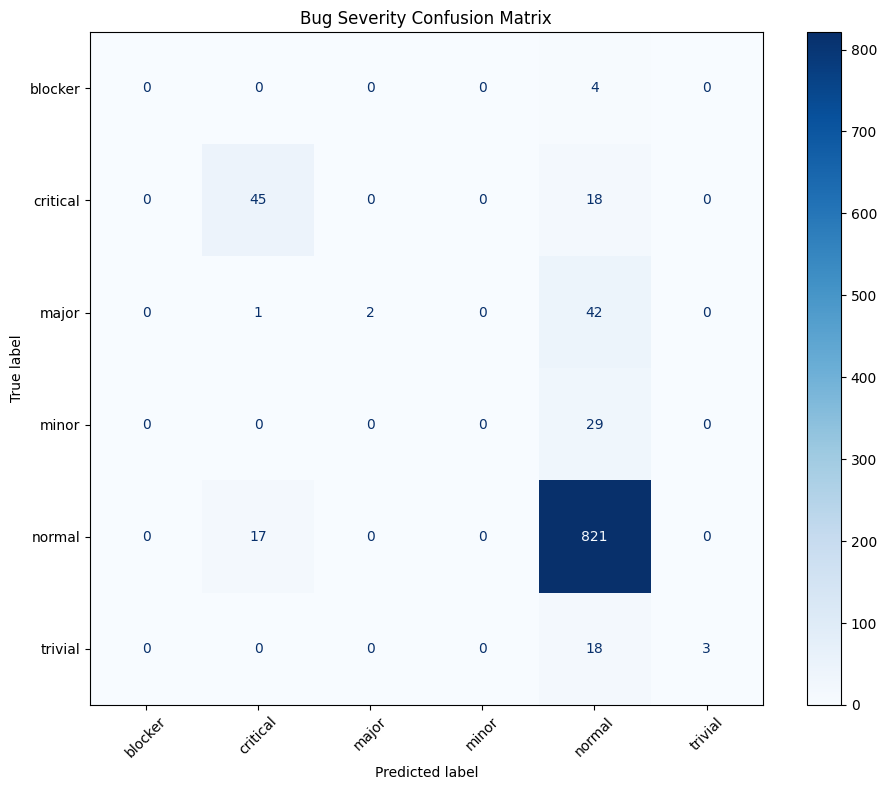

In [36]:
# Confusion Matrix

figure, axis = plt.subplots(figsize=(10, 8))

ConfusionMatrixDisplay.from_predictions(
    test_correct_labels,
    test_predicted_labels,
    labels=all_label_ids,
    display_labels=label_names,
    xticks_rotation=45,
    cmap="Blues",
    ax=axis
)

plt.title("Bug Severity Confusion Matrix")
plt.tight_layout()
plt.show()

In [38]:
# Now Load the saved model

reloaded_tokenizer = AutoTokenizer.from_pretrained(
    saved_model_directory
)

reloaded_model = AutoModelForSequenceClassification.from_pretrained(
    saved_model_directory
)

print("Saved model reloaded successfully!")
print(reloaded_model.config.id2label)

Loading weights:   0%|          | 0/138 [00:00<?, ?it/s]

Saved model reloaded successfully!
{0: 'blocker', 1: 'critical', 2: 'major', 3: 'minor', 4: 'normal', 5: 'trivial'}


In [39]:
# Now re-run new batch inference on new bug reports using the saved fine tuned model and tokenizer

new_bug_descriptions = [
    "Application crashes immediately and all unsaved data is lost.",
    "The button text is slightly misaligned on the settings page.",
    "Users cannot log in after installing the latest update.",
    "There is a spelling mistake in the help documentation."
]

# Move the reloaded model to the GPU when one is available.
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

reloaded_model = reloaded_model.to(device)

# Tokenize all bug descriptions together as one batch.
inference_inputs = reloaded_tokenizer(
    new_bug_descriptions,
    padding=True,
    truncation=True,
    max_length=MAX_TOKEN_LENGTH,
    return_tensors="pt"
)

# Move every input tensor to the same device as the model.
inference_inputs = inference_inputs.to(device)

# Put the model into inference mode.
reloaded_model.eval()

# Gradients are unnecessary because we are not training the model.
with torch.no_grad():
    model_output = reloaded_model(**inference_inputs)

In [40]:
# Convert logits to probabilities

logits = model_output.logits

probabilities = torch.softmax(
    logits,
    dim=-1
)

predicted_label_ids = torch.argmax(
    probabilities,
    dim=-1
)

print("Logits:")
print(logits)

print("\nProbabilities:")
print(probabilities)

print("\nPredicted label IDs:")
print(predicted_label_ids)

Logits:
tensor([[-1.2490,  3.3432,  2.2692, -1.1881,  1.2304, -3.5031],
        [-2.1975, -2.6416, -0.2110,  1.0475,  2.0462,  1.0466],
        [-1.5724,  0.1615,  1.9525, -0.2157,  3.0463, -2.7791],
        [-2.6695, -1.6017, -0.2067,  0.1637,  1.2963, -0.0336]],
       device='cuda:0')

Probabilities:
tensor([[0.0068, 0.6736, 0.2301, 0.0073, 0.0814, 0.0007],
        [0.0077, 0.0049, 0.0561, 0.1976, 0.5363, 0.1974],
        [0.0068, 0.0387, 0.2323, 0.0266, 0.6935, 0.0020],
        [0.0101, 0.0293, 0.1181, 0.1711, 0.5310, 0.1404]], device='cuda:0')

Predicted label IDs:
tensor([1, 4, 4, 4], device='cuda:0')


In [41]:
# Display predictions

prediction_rows = []

for index in range(len(new_bug_descriptions)):
    description = new_bug_descriptions[index]

    predicted_id = predicted_label_ids[index].item()
    predicted_severity = id_to_label[predicted_id]

    confidence = probabilities[index][predicted_id].item()

    prediction_rows.append({
        "bug_description": description,
        "predicted_severity": predicted_severity,
        "confidence": confidence
    })


prediction_table = pd.DataFrame(prediction_rows)

display(prediction_table)

,bug_description,predicted_severity,confidence
0,Application crashes immediately and all unsave...,critical,0.673622
1,The button text is slightly misaligned on the ...,normal,0.536308
2,Users cannot log in after installing the lates...,normal,0.693520
3,There is a spelling mistake in the help docume...,normal,0.531002
